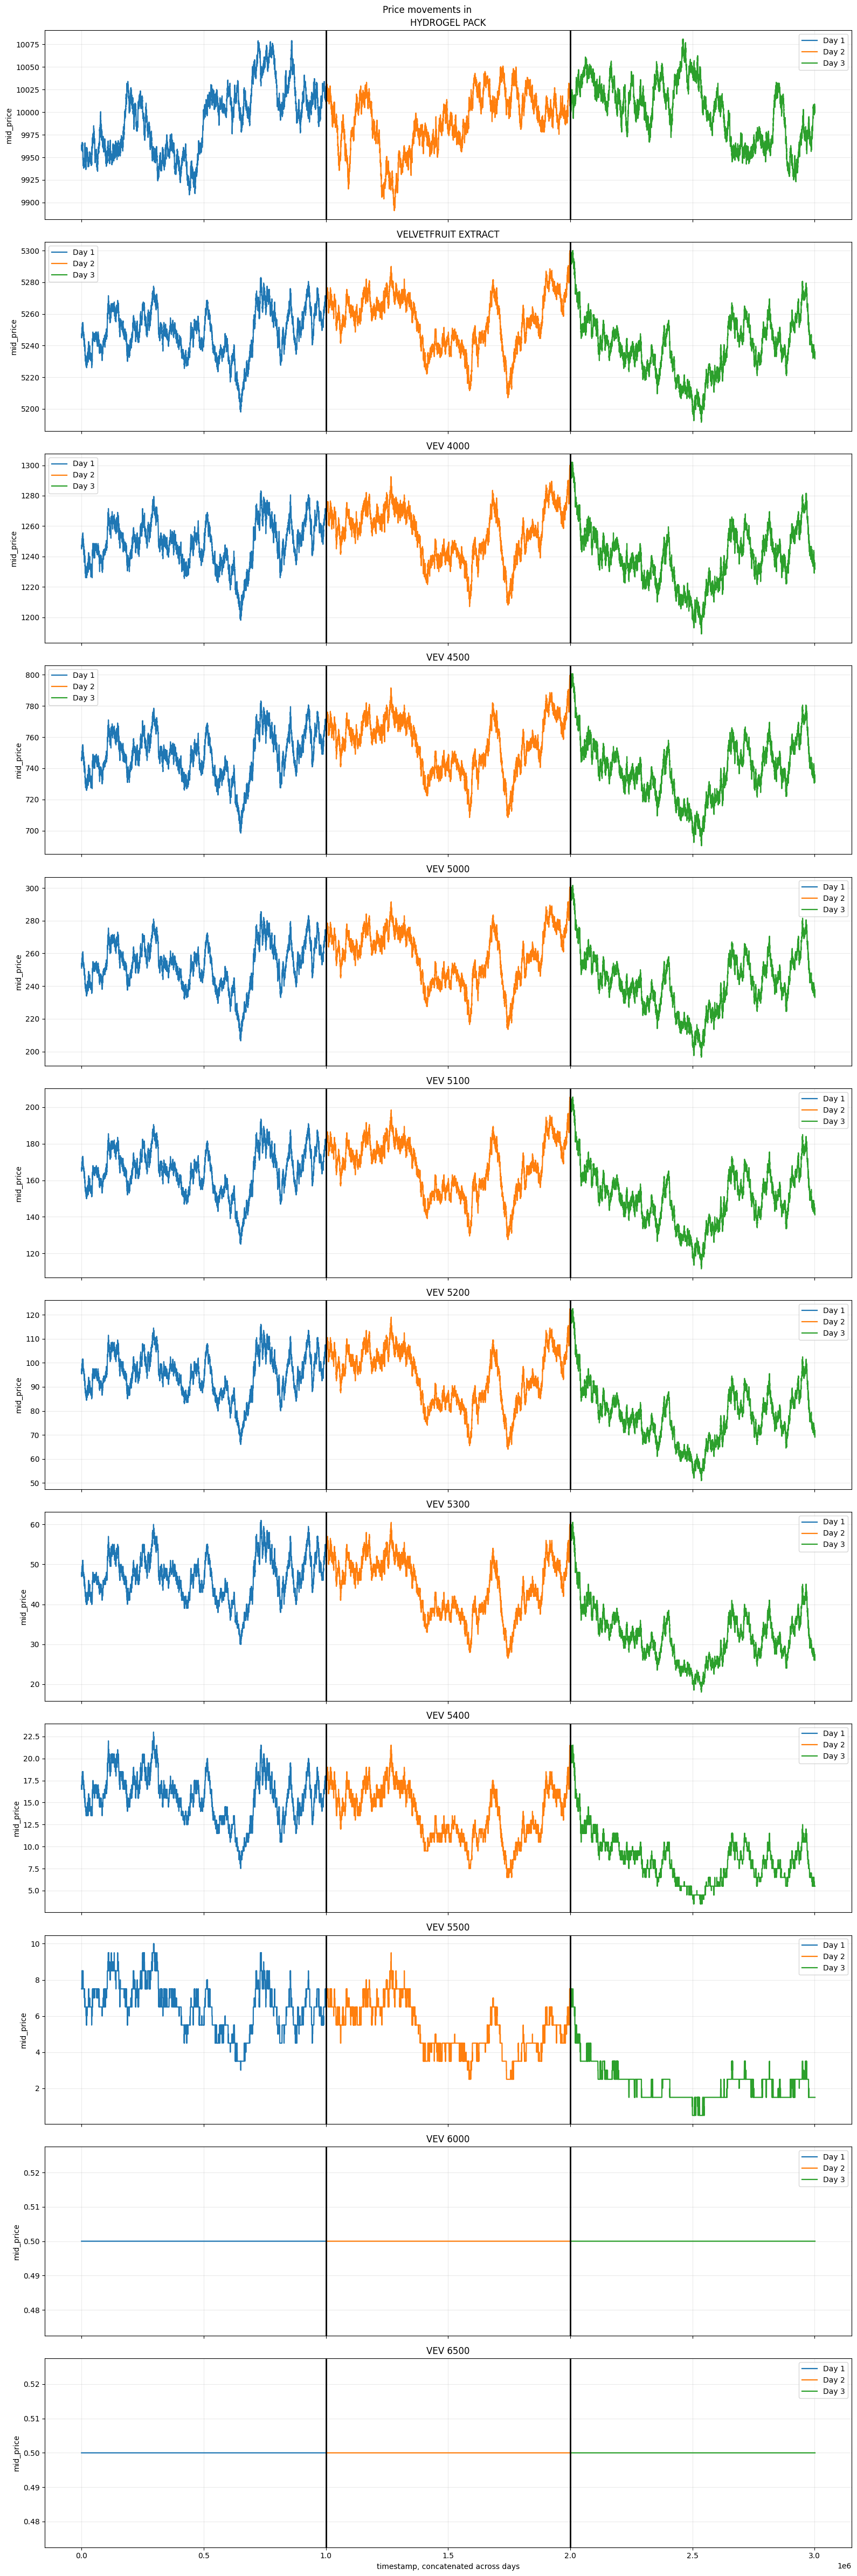

In [2]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd

ROUND_NUMBER = 4
ROUND_FOLDER = Path(".")

PRICE_FILES = sorted(ROUND_FOLDER.glob(f"prices_round_{ROUND_NUMBER}_day_*.csv"))
if not PRICE_FILES:
    raise FileNotFoundError(f"No price CSV files found in {ROUND_FOLDER}")

DAY_RE = re.compile(r"day_(-?\d+)\.csv$")
DAY_LABELS = []
frames = []
for file_path in PRICE_FILES:
    match = DAY_RE.search(file_path.name)
    if match is None:
        continue

    day = int(match.group(1))
    DAY_LABELS.append(day)

    df = pd.read_csv(file_path, sep=";")
    df["day"] = day
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df["mid_price"] = pd.to_numeric(df["mid_price"], errors="coerce")
    frames.append(df[["day", "timestamp", "product", "mid_price"]])

if not frames:
    raise ValueError(f"No valid price data found in {ROUND_FOLDER}")

DAY_LABELS = sorted(set(DAY_LABELS))
prices = pd.concat(frames, ignore_index=True).dropna(subset=["timestamp", "mid_price"])
prices["timestamp"] = prices["timestamp"].astype(float)
plot_prices = prices.loc[prices["mid_price"] > 0].copy()
products = sorted(plot_prices["product"].dropna().unique())

# Build a continuous x-axis for the days and leave a visible gap between them.
gap = 1000.0
x_offsets = {}
separator_positions = []
current_offset = 0.0
for day in DAY_LABELS:
    day_prices = plot_prices[plot_prices["day"] == day]
    max_timestamp = float(day_prices["timestamp"].max()) if not day_prices.empty else 0.0
    x_offsets[day] = current_offset
    separator_positions.append(current_offset + max_timestamp + gap / 2)
    current_offset += max_timestamp + gap

fig, axes = plt.subplots(len(products), 1, figsize=(16, max(4, 4 * len(products))), sharex=True)
if len(products) == 1:
    axes = [axes]

cmap = plt.get_cmap("tab10")
color_map = {day: cmap(i % cmap.N) for i, day in enumerate(DAY_LABELS)}

for ax, product in zip(axes, products):
    product_prices = plot_prices[plot_prices["product"] == product].sort_values(["day", "timestamp"])

    for day in DAY_LABELS:
        day_prices = product_prices[product_prices["day"] == day].sort_values("timestamp")
        if day_prices.empty:
            continue

        x_values = day_prices["timestamp"] + x_offsets[day]
        ax.plot(
            x_values,
            day_prices["mid_price"],
            color=color_map[day],
            linewidth=1.6,
            label=f"Day {day}",
        )

    for separator in separator_positions[:-1]:
        ax.axvline(separator, color="black", linewidth=2)

    ax.set_title(product.replace("_", " "))
    ax.set_ylabel("mid_price")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)

axes[-1].set_xlabel("timestamp, concatenated across days")
fig.suptitle(f"Price movements in {ROUND_FOLDER.name}", y=0.995)
fig.tight_layout()
plt.show()



VELVETFRUIT_EXTRACT: 30000 observations across days [np.int64(1), np.int64(2), np.int64(3)]

=== Augmented Dickey-Fuller Test ===
  ADF Statistic : -4.4111
  p-value       : 0.0003
  Lags used     : 4
  Critical (1%): -3.4306
  Critical (5%): -2.8616
  Critical (10%): -2.5668
  -> REJECT unit root at 5% — evidence of MEAN REVERSION

=== KPSS Test (null: stationary) ===
  KPSS Statistic: 2.4360
  p-value       : 0.0100
  Critical (10%): 0.3470
  Critical (5%): 0.4630
  Critical (2.5%): 0.5740
  Critical (1%): 0.7390
  -> REJECT stationarity at 5% — series may NOT be mean reverting

=== Hurst Exponent ===
  H = 1.0130
  -> H > 0.5 — TRENDING (momentum)

=== Half-Life of Mean Reversion (OU / OLS) ===
  Slope (lambda): -0.001968  (p=0.0000)
  Half-life     : 352.3 ticks


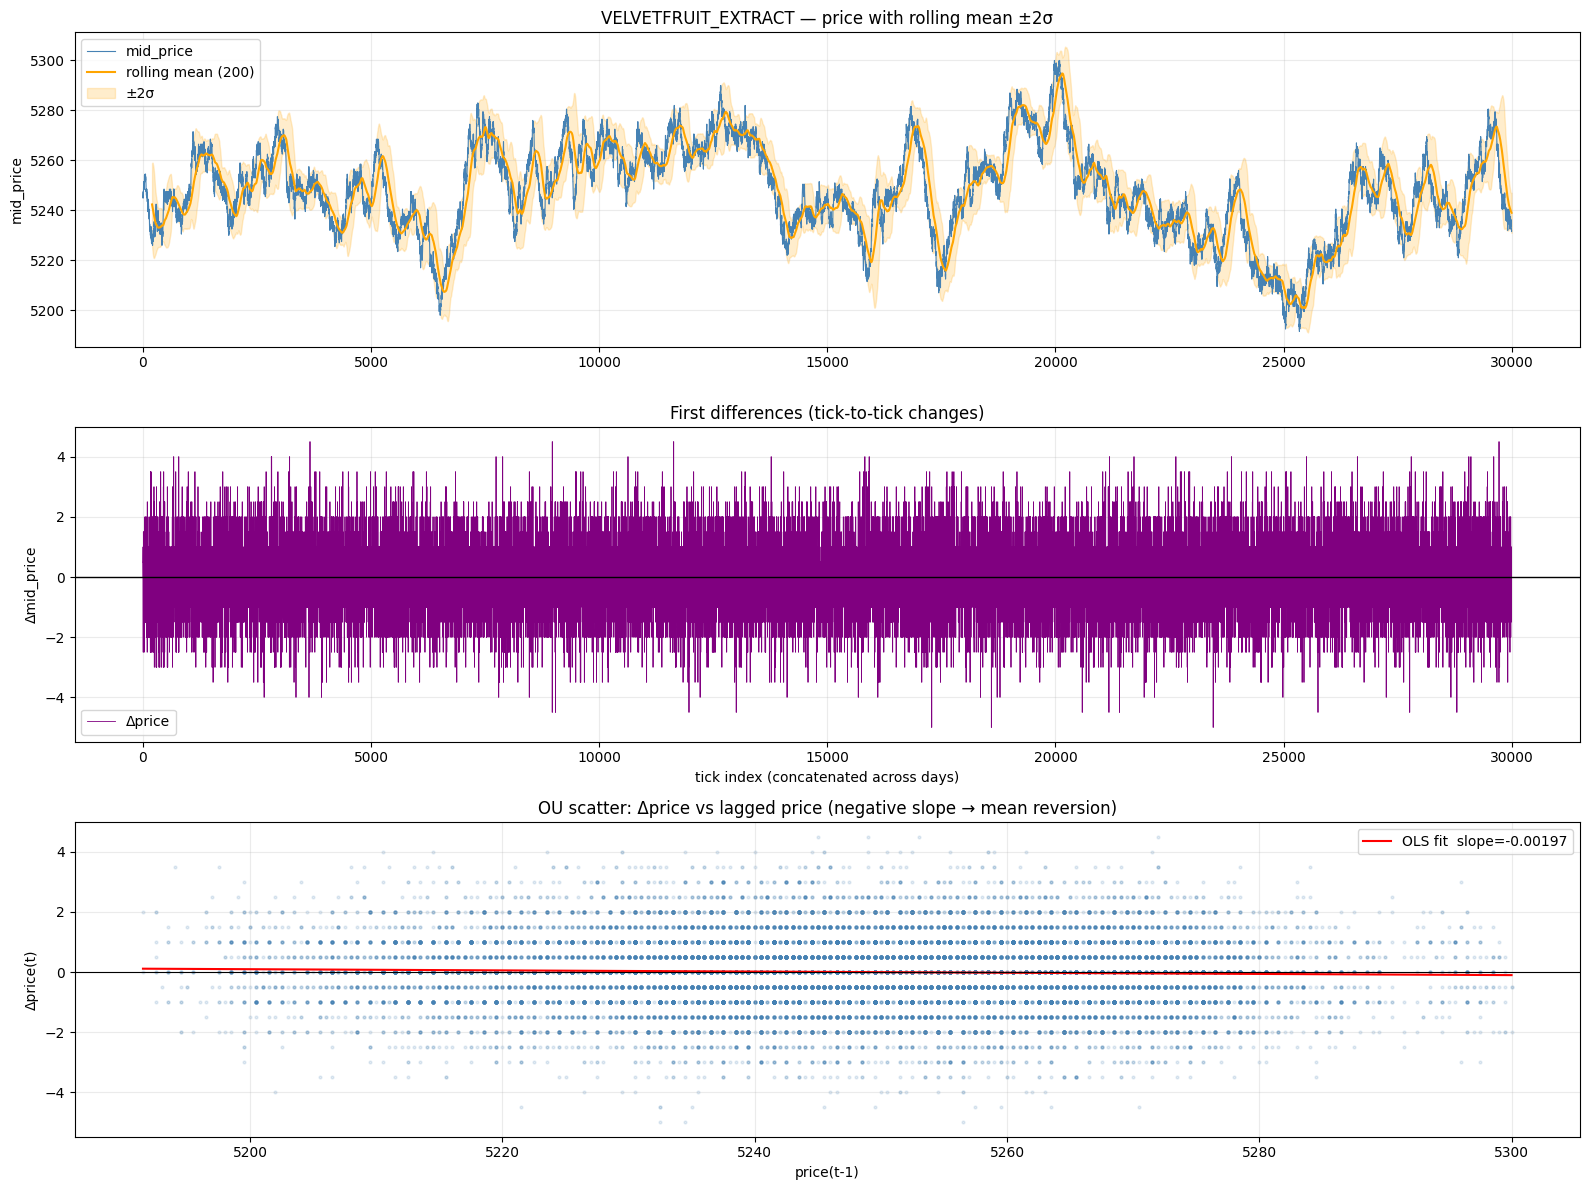

In [3]:
import numpy as np
from statsmodels.tsa.stattools import adfuller, kpss
from scipy.stats import linregress
import warnings

# Extract VELVETFRUIT_EXTRACT prices concatenated across days
vev = (
    prices[prices["product"] == "VELVETFRUIT_EXTRACT"]
    .sort_values(["day", "timestamp"])
    .reset_index(drop=True)
)
vev_prices = vev["mid_price"].values

print(f"VELVETFRUIT_EXTRACT: {len(vev_prices)} observations across days {sorted(vev['day'].unique())}\n")

# ── 1. ADF Test (null: unit root / non-stationary) ────────────────────────────
adf_result = adfuller(vev_prices, autolag="AIC")
print("=== Augmented Dickey-Fuller Test ===")
print(f"  ADF Statistic : {adf_result[0]:.4f}")
print(f"  p-value       : {adf_result[1]:.4f}")
print(f"  Lags used     : {adf_result[2]}")
for key, val in adf_result[4].items():
    print(f"  Critical ({key}): {val:.4f}")
if adf_result[1] < 0.05:
    print("  -> REJECT unit root at 5% — evidence of MEAN REVERSION")
else:
    print("  -> FAIL to reject unit root at 5% — no strong mean reversion signal")

# ── 2. KPSS Test (null: stationary) ──────────────────────────────────────────
print("\n=== KPSS Test (null: stationary) ===")
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    kpss_result = kpss(vev_prices, regression="c", nlags="auto")
print(f"  KPSS Statistic: {kpss_result[0]:.4f}")
print(f"  p-value       : {kpss_result[1]:.4f}")
for key, val in kpss_result[3].items():
    print(f"  Critical ({key}): {val:.4f}")
if kpss_result[1] > 0.05:
    print("  -> FAIL to reject stationarity at 5% — consistent with MEAN REVERSION")
else:
    print("  -> REJECT stationarity at 5% — series may NOT be mean reverting")

# ── 3. Hurst Exponent (R/S analysis) — H<0.5 mean-reverting, H>0.5 trending ──
def hurst_exponent(ts, max_lag=100):
    lags = range(2, min(max_lag, len(ts) // 2))
    rs_values = []
    for lag in lags:
        segments = [ts[i:i+lag] for i in range(0, len(ts) - lag, lag)]
        rs_per_seg = []
        for seg in segments:
            mean = np.mean(seg)
            deviate = np.cumsum(seg - mean)
            r = deviate.max() - deviate.min()
            s = np.std(seg, ddof=1)
            if s > 0:
                rs_per_seg.append(r / s)
        if rs_per_seg:
            rs_values.append((lag, np.mean(rs_per_seg)))
    if len(rs_values) < 2:
        return np.nan
    lags_arr = np.log([x[0] for x in rs_values])
    rs_arr   = np.log([x[1] for x in rs_values])
    return np.polyfit(lags_arr, rs_arr, 1)[0]

hurst = hurst_exponent(vev_prices)
print(f"\n=== Hurst Exponent ===")
print(f"  H = {hurst:.4f}")
if hurst < 0.45:
    print("  -> H < 0.5 — MEAN REVERTING")
elif hurst > 0.55:
    print("  -> H > 0.5 — TRENDING (momentum)")
else:
    print("  -> H ≈ 0.5 — close to RANDOM WALK")

# ── 4. OU Half-Life via OLS: Δp = λ·p(t-1) + c  →  half_life = -ln(2)/λ ──────
delta_p = np.diff(vev_prices)
lag_p   = vev_prices[:-1]
slope, intercept, r_val, p_val, se = linregress(lag_p, delta_p)
print(f"\n=== Half-Life of Mean Reversion (OU / OLS) ===")
print(f"  Slope (lambda): {slope:.6f}  (p={p_val:.4f})")
if slope < 0:
    half_life = -np.log(2) / slope
    print(f"  Half-life     : {half_life:.1f} ticks")
else:
    print("  Slope is positive — not mean reverting under OU model")

# ── 5. Visual diagnostics ─────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

roll = pd.Series(vev_prices)
window = 200
rolling_mean = roll.rolling(window).mean()
rolling_std  = roll.rolling(window).std()

axes[0].plot(vev_prices, linewidth=0.8, label="mid_price", color="steelblue")
axes[0].plot(rolling_mean, linewidth=1.5, label=f"rolling mean ({window})", color="orange")
axes[0].fill_between(
    range(len(vev_prices)),
    rolling_mean - 2 * rolling_std,
    rolling_mean + 2 * rolling_std,
    alpha=0.2, color="orange", label="±2σ"
)
axes[0].set_title("VELVETFRUIT_EXTRACT — price with rolling mean ±2σ")
axes[0].set_ylabel("mid_price")
axes[0].legend(); axes[0].grid(alpha=0.25)

axes[1].plot(delta_p, linewidth=0.6, color="purple", label="Δprice")
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("First differences (tick-to-tick changes)")
axes[1].set_ylabel("Δmid_price")
axes[1].set_xlabel("tick index (concatenated across days)")
axes[1].legend(); axes[1].grid(alpha=0.25)

# Scatter Δp vs p(t-1): negative slope confirms mean reversion
axes[2].scatter(lag_p, delta_p, alpha=0.15, s=4, color="steelblue")
fit_x = np.linspace(lag_p.min(), lag_p.max(), 200)
axes[2].plot(fit_x, slope * fit_x + intercept, color="red", linewidth=1.5,
             label=f"OLS fit  slope={slope:.5f}")
axes[2].axhline(0, color="black", linewidth=0.8)
axes[2].set_title("OU scatter: Δprice vs lagged price (negative slope → mean reversion)")
axes[2].set_xlabel("price(t-1)")
axes[2].set_ylabel("Δprice(t)")
axes[2].legend(); axes[2].grid(alpha=0.25)

fig.tight_layout()
plt.show()
